In [14]:
!pip install sentence-transformers matplotlib seaborn scikit-learn

In [15]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
sentences = [
    # Cricket
    "The batsman hit a six on the last ball of the over.",
    "India won the Test match by an innings and 50 runs.",
    "The spinner bowled a googly that deceived the batsman.",
    "A fast bowler can swing the ball in humid conditions.",

    # Cooking
    "Sauté the onions in olive oil until golden brown.",
    "Always preheat the oven before baking a cake.",
    "Season the pasta water generously with salt.",

    # Cybersecurity
    "A phishing attack tricks users into revealing their passwords.",
    "Firewalls monitor and filter incoming network traffic.",
    "Two-factor authentication adds an extra layer of security.",
]

print(f"Total sentences: {len(sentences)}")

Total sentences: 10


In [17]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings created!")
print(f"Shape: {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings created!
Shape: (10, 384)


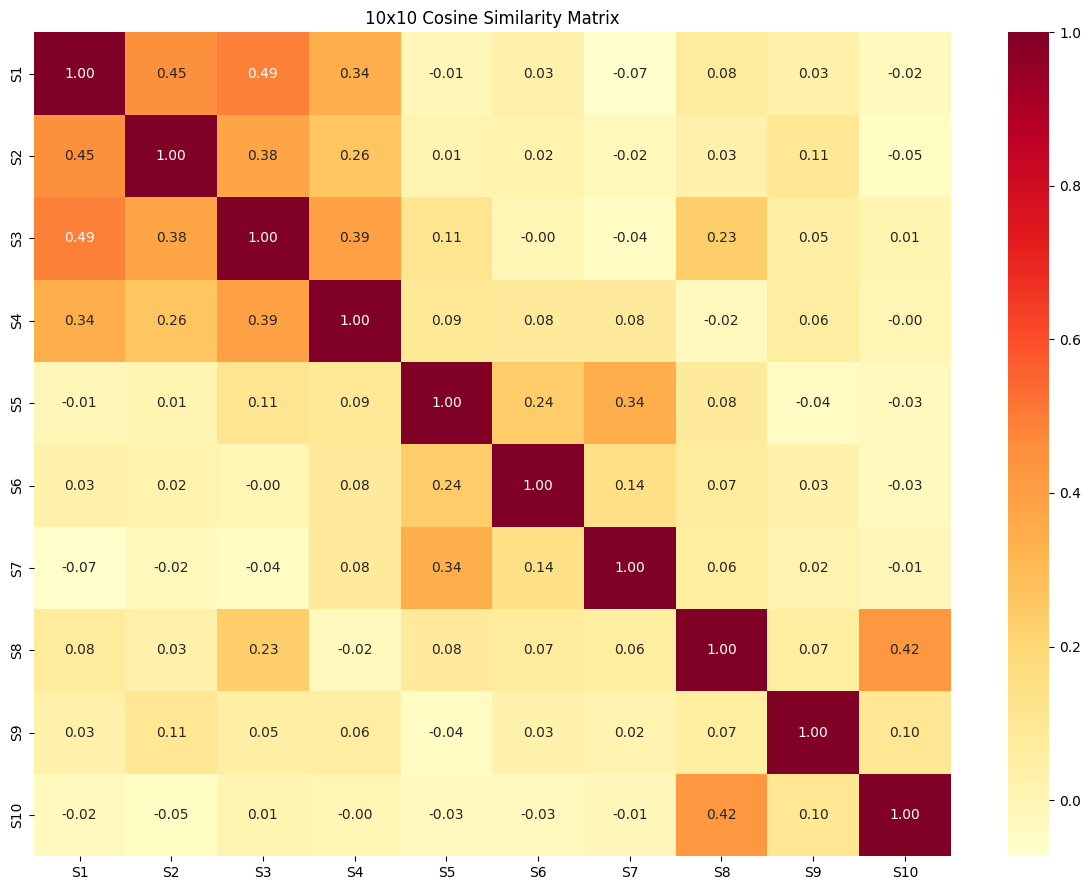

In [18]:
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(12, 9))
labels = [f"S{i+1}" for i in range(len(sentences))]
sns.heatmap(sim_matrix, annot=True, fmt=".2f", xticklabels=labels,
            yticklabels=labels, cmap="YlOrRd")
plt.title("10x10 Cosine Similarity Matrix")
plt.tight_layout()
plt.show()

In [19]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]
top2_indices = np.argsort(scores)[::-1][:2]

print(f"Query: {query}\n")
for idx in top2_indices:
    print(f"Score: {scores[idx]:.4f} | Sentence: {sentences[idx]}")

Query: The bowler took three wickets in one over

Score: 0.6088 | Sentence: The batsman hit a six on the last ball of the over.
Score: 0.5763 | Sentence: The spinner bowled a googly that deceived the batsman.
